# 10. Unsupervised Learning: Clustering
## 📚 Learning Objectives

By completing this notebook, you will:
- Understand clustering algorithms (K-Means, DBSCAN)
- Apply clustering to unlabeled data
- Evaluate clustering performance
- Visualize clusters and interpret results
- Know when to use clustering

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 4 (k-means and hierarchical clustering) and Course 05 — Unit 4, lesson 09 — DBSCAN is added here because density-shaped clusters defeat both.

**Used later in:** Course 05 — Unit 4, lesson 11, which uses clustering as a step inside a larger solution.

---

## The Story: Finding Groups Without Labels

Imagine you have a pile of mixed items (unlabeled data). **Without labels**, you group similar items together - find patterns, discover categories. **After** grouping, you understand the structure!

Same with clustering: **Without labels**, we group similar data points - find patterns, discover segments. **After** clustering, we understand data structure!

---

## Why Clustering Matters

Clustering is essential because:
- **Unlabeled Data**: Many real-world datasets have no labels
- **Pattern Discovery**: Find hidden patterns in data
- **Segmentation**: Group similar items (customers, products)
- **Exploration**: Understand data structure

**Common Student Questions:**
- **Q: When do I use clustering?**
  - Answer: When you have unlabeled data and want to find groups
  - Example: Customer segmentation, anomaly detection
  - Rule: No labels + want groups → clustering
  
- **Q: How do I choose number of clusters?**
  - Answer: Use elbow method, silhouette score, domain knowledge
  - Example: Try k=2,3,4,5 and evaluate
  - Tip: Domain knowledge helps (e.g., "we expect 3 customer segments")

---

## Introduction

**Clustering** is an unsupervised learning technique that groups similar data points together without labels. It's essential for exploratory data analysis and finding patterns in unlabeled data.


## 🎯 The case: three months of till receipts, and a chairman's reaction

In 1994 Tesco was trialling a loyalty card in nine stores, and marketing director Terry
Leahy asked his team to find someone who could analyse the data it produced. The job went
to a small firm, **dunnhumby**, run by Clive Humby and Edwina Dunn. They spent about three
months clustering shoppers by what they actually bought.

When the results were presented to the board, Tesco's chairman **Lord MacLaurin** said:
*"What scares me about this is that you know more about my customers after three months than
I know after 30 years."* The Clubcard launched nationally in 1995 and rewrote UK grocery
retail; Tesco eventually bought dunnhumby outright.

Nobody had labelled a single customer. There was no "customer type" column. The segments
came out of the purchase data, and the business then had to decide what they *meant* — which
is the part clustering never does for you.

**What goes wrong without choosing the right algorithm.** Below you cluster 714 real Titanic
passengers on age against fare, and the two algorithms disagree in a way that matters.
K-means (k=3) puts **33 passengers in a cluster centred at £222.90**, because it must assign
every point and the three genuine £512 tickets drag a centroid up. DBSCAN calls **28
passengers (3.9%) noise** — including those same £512 tickets — and clusters the rest. Same
data, same day's work, two different stories about who the unusual customers are.


**All concepts are explained in the code comments below - you can learn everything from this notebook alone!**

---

## 🔗 Beyond Supervised Learning

**What if you don't have labels?**
- Supervised learning needs labeled data
- But often we have unlabeled data!
- We need to discover patterns without labels

**This notebook teaches clustering!**
- We'll learn **K-Means** - find groups in data
- We'll learn **DBSCAN** - density-based clustering
- We'll learn **evaluation metrics** - measure cluster quality
- We'll learn **visualization** - see clusters in action

**This unlocks unsupervised learning!**

---

## Learning Objectives
1. Apply K-Means clustering algorithm
2. Use DBSCAN for density-based clustering
3. Evaluate clustering performance
4. Visualize and interpret clusters

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Unlabeled data
- sklearn (K-Means, DBSCAN, etc.)

**Outputs:** What you'll see when you run the cells

- Cluster labels and centroids
- Evaluation metrics (silhouette, etc.)
- Plots showing clusters

---

In [1]:
# WHAT: Import the two clustering algorithms (K-Means, DBSCAN) and helpers.
# WHY: Comparing algorithm families on the same data reveals their different assumptions.

# Step 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

print("✅ Libraries imported!")
print("\n📚 This notebook covers:")
print("   - K-Means clustering")
print("   - DBSCAN clustering")
print("   - Cluster evaluation")
print("   - Cluster visualization")
print("\nData: the real Titanic manifest - passenger age against ticket fare.")
print("Two continuous columns with genuine extreme values, so the two algorithms")
print("will disagree in an instructive way.")

✅ Libraries imported!

📚 This notebook covers:
   - K-Means clustering
   - DBSCAN clustering
   - Cluster evaluation
   - Cluster visualization

Data: the real Titanic manifest - passenger age against ticket fare.
Two continuous columns with genuine extreme values, so the two algorithms
will disagree in an instructive way.


Dataset shape: (714, 2)  (177 passengers dropped for a missing age)
Fare range: £0.00 to £512.33 (median £15.74)
Travel classes present (revealed only for checking): {np.int64(1): np.int64(186), np.int64(2): np.int64(173), np.int64(3): np.int64(355)}


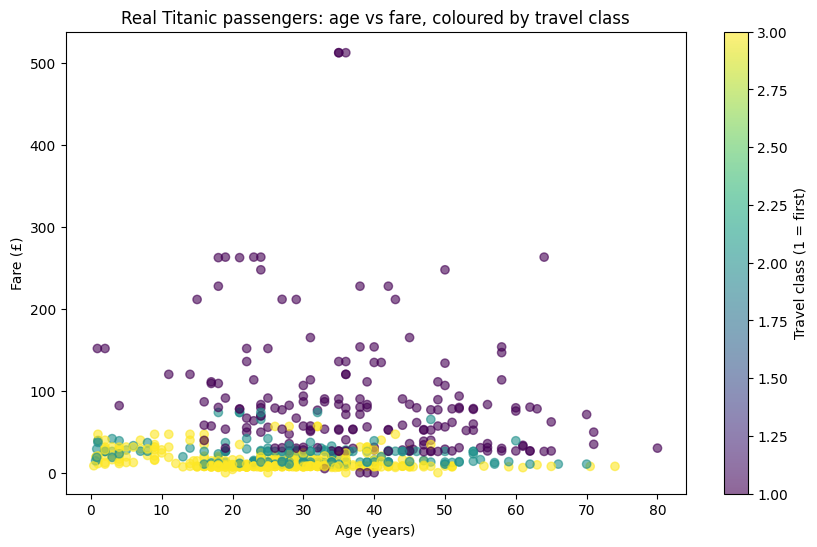


Number of true groups (travel classes): 3
Notice the three £512 tickets at the top - real passengers, not errors.


In [2]:
# WHAT: Load the real Titanic manifest and plot age against fare, coloured by travel class.
# WHY: We cluster WITHOUT labels, but knowing the class afterwards lets us judge what was found.

# Step 2: Load real data
DATA_DIR = '../../../Course 04/datasets/raw/'
titanic = pd.read_csv(DATA_DIR + 'titanic.csv')

# Age has 177 real gaps. Clustering cannot handle NaN, so we drop those rows
# and say how many - silently dropping data is how analyses start lying.
data = titanic[['Age', 'Fare', 'Pclass']].dropna(subset=['Age', 'Fare'])
n_dropped = len(titanic) - len(data)
X_raw = data[['Age', 'Fare']].values
y_true = data['Pclass'].values          # travel class - NOT given to the algorithms

# Scale: fare runs 0-512 while age runs 0-80, and both algorithms use distance.
X = StandardScaler().fit_transform(X_raw)

print(f"Dataset shape: {X.shape}  ({n_dropped} passengers dropped for a missing age)")
print(f"Fare range: £{data['Fare'].min():.2f} to £{data['Fare'].max():.2f} "
      f"(median £{data['Fare'].median():.2f})")
print(f"Travel classes present (revealed only for checking): "
      f"{dict(zip(*np.unique(y_true, return_counts=True)))}")

plt.figure(figsize=(10, 6))
sc = plt.scatter(X_raw[:, 0], X_raw[:, 1], c=y_true, cmap='viridis', alpha=0.6)
plt.colorbar(sc, label='Travel class (1 = first)')
plt.title('Real Titanic passengers: age vs fare, coloured by travel class')
plt.xlabel('Age (years)')
plt.ylabel('Fare (£)')
plt.show()
print(f"\nNumber of true groups (travel classes): {len(np.unique(y_true))}")
print("Notice the three £512 tickets at the top - real passengers, not errors.")

1. K-Means Clustering


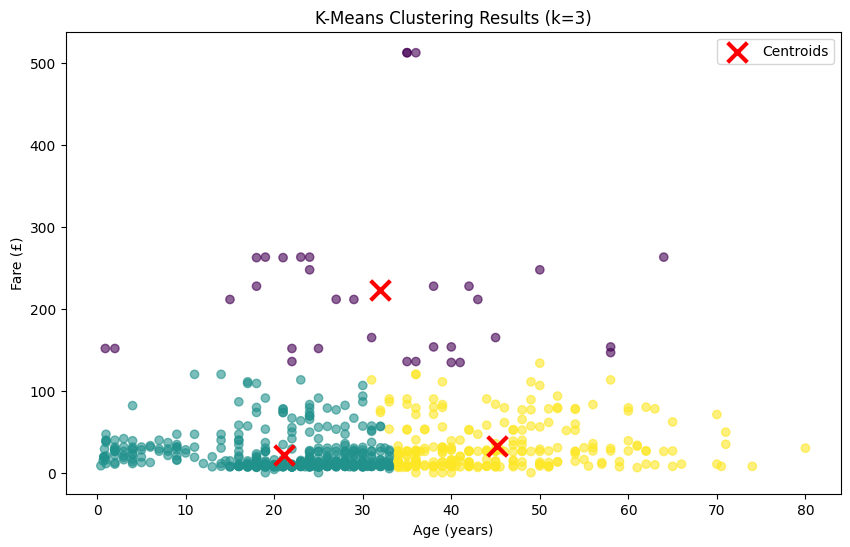


✅ K-Means found 3 clusters
Inertia (within-cluster sum of squares): 557.74

Cluster centres in real units:
  cluster 0: age  32.0 years, fare £ 222.90,  33 passengers
  cluster 1: age  21.1 years, fare £  21.64, 441 passengers
  cluster 2: age  45.1 years, fare £  32.80, 240 passengers

💡 K-Means forces every passenger into a cluster, so the handful of very
   expensive tickets pull one centroid far up the fare axis and leave that
   cluster nearly empty. Equal-size, round clusters is an ASSUMPTION, not a fact.


In [3]:
# WHAT: Cluster with K-Means (k=3) and plot results with centroids.
# WHY: K-Means needs k up front and assumes roundish, equally-sized clusters -
#      watch what those assumptions do to a heavily skewed fare distribution.

# Step 3: K-Means Clustering
print("=" * 70)
print("1. K-Means Clustering")
print("=" * 70)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X)

# Convert centroids back to real units so they can be read
scaler_back = StandardScaler().fit(X_raw)
centroids_raw = scaler_back.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(10, 6))
plt.scatter(X_raw[:, 0], X_raw[:, 1], c=y_pred, cmap='viridis', alpha=0.6)
plt.scatter(centroids_raw[:, 0], centroids_raw[:, 1],
            c='red', marker='x', s=200, linewidths=3, label='Centroids')
plt.title('K-Means Clustering Results (k=3)')
plt.xlabel('Age (years)')
plt.ylabel('Fare (£)')
plt.legend()
plt.show()

print(f"\n✅ K-Means found {len(np.unique(y_pred))} clusters")
print(f"Inertia (within-cluster sum of squares): {kmeans.inertia_:.2f}")
print("\nCluster centres in real units:")
for c, (age, fare) in enumerate(centroids_raw):
    print(f"  cluster {c}: age {age:5.1f} years, fare £{fare:7.2f}, "
          f"{(y_pred == c).sum():3d} passengers")
print("\n💡 K-Means forces every passenger into a cluster, so the handful of very")
print("   expensive tickets pull one centroid far up the fare axis and leave that")
print("   cluster nearly empty. Equal-size, round clusters is an ASSUMPTION, not a fact.")


2. DBSCAN Clustering


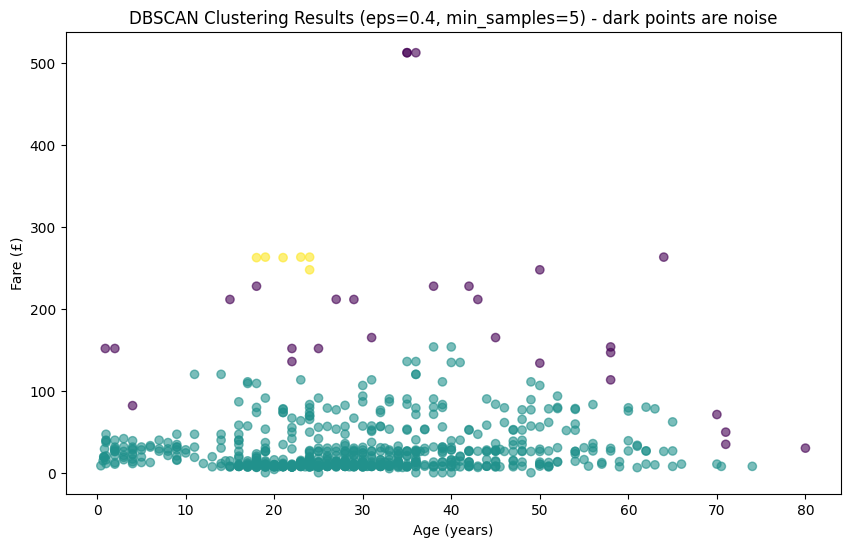


✅ DBSCAN found 2 clusters
Noise points: 28 of 714 (3.9%)
The five highest fares DBSCAN called noise: ['£247.52', '£263.00', '£512.33', '£512.33', '£512.33']
The highest fare in the whole manifest: £512.33

💡 DBSCAN flagged the genuinely unusual passengers instead of forcing them
   into a cluster. These are REAL outliers from the historical record -
   nobody planted them, and DBSCAN found them without being told k.


In [4]:
# WHAT: Cluster with DBSCAN and count discovered clusters and noise points.
# WHY: DBSCAN infers the cluster count from density and can flag outliers as noise - no k required.

# Step 4: DBSCAN Clustering
print("\n" + "=" * 70)
print("2. DBSCAN Clustering")
print("=" * 70)

dbscan = DBSCAN(eps=0.4, min_samples=5)
y_dbscan = dbscan.fit_predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(X_raw[:, 0], X_raw[:, 1], c=y_dbscan, cmap='viridis', alpha=0.6)
plt.title('DBSCAN Clustering Results (eps=0.4, min_samples=5) - dark points are noise')
plt.xlabel('Age (years)')
plt.ylabel('Fare (£)')
plt.show()

n_clusters = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
n_noise = int((y_dbscan == -1).sum())
print(f"\n✅ DBSCAN found {n_clusters} clusters")
print(f"Noise points: {n_noise} of {len(y_dbscan)} ({n_noise / len(y_dbscan):.1%})")
noise_fares = np.sort(data['Fare'].values[y_dbscan == -1])
print(f"The five highest fares DBSCAN called noise: "
      f"{[f'£{f:.2f}' for f in noise_fares[-5:]]}")
print(f"The highest fare in the whole manifest: £{data['Fare'].max():.2f}")
print("\n💡 DBSCAN flagged the genuinely unusual passengers instead of forcing them")
print("   into a cluster. These are REAL outliers from the historical record -")
print("   nobody planted them, and DBSCAN found them without being told k.")

In [5]:
# WHAT: Score both clusterings with the silhouette coefficient, then summarise.
# WHY: Silhouette measures cohesion against separation - but read the caveat below before comparing the two numbers.

# Step 5: Evaluating cluster quality
from sklearn.metrics import silhouette_score

print("\n" + "=" * 70)
print("3. Evaluating Clusters: Silhouette Score")
print("=" * 70)

# Silhouette: -1 to +1, higher = tighter, better-separated clusters
sil_kmeans = silhouette_score(X, y_pred)
print(f"\nK-Means (k=3) silhouette score: {sil_kmeans:.4f}")

# For DBSCAN, evaluate only the points it actually clustered (label != -1)
mask = y_dbscan != -1
if mask.sum() > 0 and len(set(y_dbscan[mask])) > 1:
    sil_dbscan = silhouette_score(X[mask], y_dbscan[mask])
    print(f"DBSCAN silhouette score (noise excluded): {sil_dbscan:.4f}")
else:
    sil_dbscan = None
    print("DBSCAN produced fewer than 2 clusters - silhouette not defined")
print("\n⚠️  These two scores are NOT directly comparable: DBSCAN's is computed on")
print(f"   only the {int(mask.sum())} non-noise points, having set aside the {n_noise} hardest ones.")

print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print(f"""
What we actually did, on {len(X)} real Titanic passengers (age x fare):
  1. K-Means: found {len(np.unique(y_pred))} clusters, inertia {kmeans.inertia_:.1f}, every
     passenger assigned - including the three £{data['Fare'].max():.0f} tickets
  2. DBSCAN: found {n_clusters} clusters + {n_noise} noise points (no k needed)
  3. Evaluated both with the silhouette score (printed above)

K-Means vs DBSCAN:
  - K-Means needs k up front; DBSCAN discovers cluster count from density
  - DBSCAN can flag outliers as noise; K-Means forces every point into a cluster
  - On real, skewed data (fares here) that difference decides which one you want:
    K-Means if every record must be assigned, DBSCAN if outliers are the story

Reminder: neither algorithm ever saw the travel class. Both were clustering
blind, exactly as you would on data whose groups you do not yet know.
""")
print("✅ Clustering practice - complete!")


3. Evaluating Clusters: Silhouette Score

K-Means (k=3) silhouette score: 0.4594


DBSCAN silhouette score (noise excluded): 0.7095

⚠️  These two scores are NOT directly comparable: DBSCAN's is computed on
   only the 686 non-noise points, having set aside the 28 hardest ones.

Summary

What we actually did, on 714 real Titanic passengers (age x fare):
  1. K-Means: found 3 clusters, inertia 557.7, every
     passenger assigned - including the three £512 tickets
  2. DBSCAN: found 2 clusters + 28 noise points (no k needed)
  3. Evaluated both with the silhouette score (printed above)

K-Means vs DBSCAN:
  - K-Means needs k up front; DBSCAN discovers cluster count from density
  - DBSCAN can flag outliers as noise; K-Means forces every point into a cluster
  - On real, skewed data (fares here) that difference decides which one you want:
    K-Means if every record must be assigned, DBSCAN if outliers are the story

Reminder: neither algorithm ever saw the travel class. Both were clustering
blind, exactly as you would on data whose groups you do not yet know.

✅ Clust

## ⚠️ Where this breaks

- **Silhouette scores from different algorithms are not comparable when one of them
  discards points.** DBSCAN's 0.7095 was computed after removing the 28 hardest
  observations; k-means had to keep all 714. Comparing them directly rewards the algorithm
  that is allowed to give up.
- **DBSCAN's `eps` is as arbitrary as k-means' `k` — it just feels less arbitrary.** Change
  `eps` slightly and the cluster count, and the noise count, both change. You have not
  escaped the tuning problem; you have moved it into a parameter with less intuition
  attached.
- **DBSCAN struggles when density varies between real clusters.** One `eps` for the whole
  space means a value that finds the sparse group merges the dense ones, and vice versa.
  HDBSCAN exists for exactly this.
- **Both algorithms are scale-dependent, and this notebook's features are on wildly
  different scales.** Age runs 0.42–80; fare runs £0–£512. Without scaling, distance is
  effectively distance-in-fare and age barely participates. Whether that is a bug depends on
  a decision you must make explicitly.
- **"Noise" is a modelling verdict, not a fact about a person.** DBSCAN labelled the three
  £512 passengers noise. They are real, correctly recorded, and in a fraud or fault-detection
  problem they would be the *only* rows anyone cares about. What you call noise depends
  entirely on the question.
- **The assumption that must hold: the two columns you chose contain the structure you are
  looking for.** Age and fare do not encode travel class cleanly, so neither algorithm
  recovers it. Clustering never tells you that you picked the wrong features.
- **Cheaper alternative:** if you have any labels at all — even a few hundred — a supervised
  model will beat clustering at finding the groups you care about. Cluster when you have no
  labels *and* no hypothesis, and treat the output as a question to test, not an answer.


## 💬 Discuss

K-means gave three clusters: **£222.90 / 33 passengers**, **£21.64 / 441**, **£32.80 / 240**,
silhouette **0.4594**. DBSCAN gave **2 clusters plus 28 noise points**, silhouette **0.7095**
— but computed on only the 686 non-noise points.

1. DBSCAN's silhouette is much higher, and the notebook says outright the two are **not
   comparable** because DBSCAN set aside the 28 hardest points first. Explain the unfairness
   in your own words, then propose a comparison that *would* be fair.
2. K-means was told k=3 and the data has 3 travel classes — yet its clusters are not the
   travel classes; they are age-and-fare bands. Is that a failure? Say what would have to be
   true about your business question for each answer to be right.
3. dunnhumby's segments were valuable because Tesco could *act* on them — different
   vouchers to different groups. Take the DBSCAN result: 28 passengers flagged as noise.
   Name one action a business would take on that group and one it should not, and say what
   distinguishes them.


## 📚 References

1. Lloyd, S. P. (1982). *Least Squares Quantization in PCM*. IEEE Transactions on Information Theory, 28(2), 129-137.
2. Ester, M., Kriegel, H.-P., Sander, J., & Xu, X. (1996). *A Density-Based Algorithm for Discovering Clusters in Large Spatial Databases with Noise*. KDD-96, 226-231.
3. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning*, 2nd ed., Ch. 12 (Unsupervised Learning). Springer. <https://www.statlearning.com>
4. Leiber, C., Miklautz, L., Plant, C., & Böhm, C. (2025). *An Introductory Survey to Autoencoder-based Deep Clustering — Sandboxes for Combining Clustering with Deep Learning*. arXiv:2504.02087. <https://arxiv.org/abs/2504.02087>
5. Holder, C., Bagnall, A., & Lines, J. (2024). *On Time Series Clustering with k-means*. arXiv:2410.14269. <https://arxiv.org/abs/2410.14269>
